# Metabolomics Case Study - Diabetes Risk  
Investigation of blood biomarkers for diabetes risk

## Variables:  
- existing_diabetes (1 if had diabetes at the time of study, else 0)
- incident_diabetes (1 if participants developed diabetes during the study, else 0)
- diabetes_time:  
  - if incident_diabetes=1: number of years it took to develop diabetes
  - if existing_diabetes=1: number of years the diagnosis of diabetes was made prior to baseline enrollment, and is a negative value  
  - if no diabetes at any time: number of years of follow up time since baseline enrollment  
- demographic variables: age, sex, BMI
- mtb_* indicate blood biomarkers
  - missing values indicate very low detection levels

### Exploratory Data Analysis

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('data/test_project_data.csv')
df.head()

,subject_id,mtb_0018261,mtb_0018266,mtb_0018325,mtb_0018326,mtb_0018327,mtb_0018351,mtb_0018362,mtb_0018470,mtb_0018509,...,mtb_2127305,mtb_2129124,mtb_2129210,mtb_2129554,BMI,age,sex,prevalent_diabetes,incident_diabetes,diabetes_followup_time
0,sbj_0000,5885.011,15177.95,19653.31,12611.670,9042.063,NaN,60124.56,9552.881,NaN,...,NaN,NaN,22112.25,NaN,18.664268,33.81,male,0.0,0.0,14.77
1,sbj_0001,7624.425,10901.94,12129.36,9336.460,21680.930,NaN,83700.80,15068.120,NaN,...,NaN,NaN,NaN,NaN,28.175977,68.56,male,0.0,0.0,14.77
2,sbj_0002,7220.400,18086.69,23707.55,7344.697,26314.650,NaN,82482.38,13911.300,NaN,...,15185.790,NaN,19425.35,NaN,22.971959,55.68,male,0.0,0.0,14.77
3,sbj_0003,6797.486,12364.85,17775.76,25836.150,30563.140,NaN,92839.12,11690.130,NaN,...,NaN,NaN,NaN,NaN,21.960370,43.89,female,0.0,0.0,14.78
4,sbj_0004,NaN,19046.33,18701.06,14137.270,27020.920,NaN,85453.69,9579.896,NaN,...,5318.547,NaN,NaN,NaN,40.454949,47.76,male,0.0,0.0,14.86


In [10]:
df.shape

(8291, 10007)

This is the curse of dimensionality plaguing our dataset. We have a lot more features than samples! Since we are designing a predictive diabetes model and suggesting a blood panel, and we want to deploy this model to predict disease risk on new data, we need to whittle down the biomarkers quite a bit.

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mtb_0018261,6959.0,10184.705605,5334.255467,1754.890000,8377.128000,9284.60000,10312.555000,1.009165e+05
mtb_0018266,6047.0,20787.074194,17970.314250,717.575400,10944.940000,16846.00000,24526.130000,2.656074e+05
mtb_0018325,6412.0,10655.320036,5769.337485,1006.217000,7861.506750,10003.12000,12244.505000,1.513797e+05
mtb_0018326,3752.0,13554.778449,9647.557144,399.922800,8665.426750,11658.32000,15296.572500,1.136382e+05
mtb_0018327,4999.0,19314.922160,20072.227554,1545.612000,11977.220000,15814.59000,21474.030000,1.031950e+06
...,...,...,...,...,...,...,...,...
BMI,8287.0,26.918973,4.671872,15.836757,23.635075,26.32401,29.431875,5.597963e+01
age,8291.0,48.042692,13.149461,24.100000,37.260000,48.53000,58.345000,7.424000e+01
prevalent_diabetes,8148.0,0.055351,0.228678,0.000000,0.000000,0.00000,0.000000,1.000000e+00
incident_diabetes,8148.0,0.086402,0.280973,0.000000,0.000000,0.00000,0.000000,1.000000e+00


We will need to scale the data, likely a log2 transformation because the columns have quite a range of units

In [18]:
df['prevalent_diabetes'].value_counts()

prevalent_diabetes
0.0    7697
1.0     451
Name: count, dtype: int64

In [19]:
df['incident_diabetes'].value_counts()

incident_diabetes
0.0    7444
1.0     704
Name: count, dtype: int64

For this analysis, we are interested in understanding the risk of developing diabetes.

Pre-train_test_split feature engineering - unorthodox in data science workflows, but constructing the target Y variable is required for stratification of the train-test-split. Other values in the dataset do not influence the classification of individual rows as 1 or 0.  

Construct new Y variable: has_diabetes=1:  
    The patients who started the study without diabetes (prevalent_diabetes=0) and developed it over time (incident_diabetes=1)  
    The patients who started the study with diabetes (prevalent_diabetes=1)  
has_diabetes=0:  
    prevalent_diabetes = 0 & incident_diabetes=0

This has_diabetes variable will be the stratification for our train_test_split

In [21]:
df.groupby(['prevalent_diabetes','incident_diabetes']).size()

prevalent_diabetes  incident_diabetes
0.0                 0.0                  6993
                    1.0                   704
1.0                 0.0                   451
dtype: int64

In [36]:
df[(df['prevalent_diabetes'] == 0) & (df['incident_diabetes'] == 1)]

df[((df['prevalent_diabetes'] == 0) & (df['incident_diabetes'] == 1)) | (df['prevalent_diabetes'] == 1)]

,subject_id,mtb_0018261,mtb_0018266,mtb_0018325,mtb_0018326,mtb_0018327,mtb_0018351,mtb_0018362,mtb_0018470,mtb_0018509,...,mtb_2127305,mtb_2129124,mtb_2129210,mtb_2129554,BMI,age,sex,prevalent_diabetes,incident_diabetes,diabetes_followup_time
8,sbj_0008,6381.261,11864.460,9896.124,5710.429,23579.490,NaN,78010.90,9099.404,NaN,...,6486.551,NaN,NaN,NaN,32.996551,32.73,male,0.0,1.0,7.88
18,sbj_0018,7601.317,NaN,5918.784,NaN,3923.366,NaN,18516.41,17609.910,NaN,...,NaN,NaN,NaN,NaN,31.328312,61.36,male,0.0,1.0,8.55
20,sbj_0020,7540.105,4329.825,6862.309,6794.757,7822.389,NaN,61724.64,6967.305,NaN,...,NaN,NaN,NaN,NaN,34.069880,56.79,female,0.0,1.0,6.49
26,sbj_0026,NaN,38482.010,30162.620,60281.120,79190.470,NaN,428960.80,14854.280,31581.65,...,NaN,NaN,NaN,NaN,28.360740,49.93,male,0.0,1.0,8.17
39,sbj_0039,NaN,32165.110,15535.210,37637.970,209049.500,NaN,227746.70,17895.120,15806.66,...,NaN,NaN,NaN,NaN,29.076581,53.01,male,0.0,1.0,6.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8255,sbj_8255,8558.250,67224.060,7687.792,NaN,NaN,NaN,62076.97,14815.220,NaN,...,NaN,NaN,13729.16,NaN,26.352390,59.36,male,1.0,0.0,NaN
8256,sbj_8256,8880.749,127997.200,11286.180,11658.320,NaN,NaN,65585.55,17304.740,NaN,...,NaN,14431.87,15111.69,NaN,31.575674,52.42,male,1.0,0.0,-4.35
8271,sbj_8271,10214.810,25039.860,13795.220,NaN,NaN,NaN,91569.59,133939.900,NaN,...,NaN,NaN,NaN,NaN,37.722910,61.76,female,0.0,1.0,3.23
8272,sbj_8272,17544.760,15234.750,2327.377,3937.588,NaN,NaN,103729.50,51885.390,NaN,...,NaN,NaN,NaN,NaN,30.449827,49.00,male,0.0,1.0,11.79


In [37]:
((df['prevalent_diabetes'] == 0) & (df['incident_diabetes'] == 1)) | (df['prevalent_diabetes'] == 1)

0       False
1       False
2       False
3       False
4       False
        ...  
8286    False
8287    False
8288    False
8289    False
8290    False
Length: 8291, dtype: bool

In [49]:
# create has_diabetes column
condition = [
    ((df['prevalent_diabetes'] == 0) & (df['incident_diabetes'] == 1)) | (df['prevalent_diabetes'] == 1),
    (df['prevalent_diabetes'] == 0) & (df['incident_diabetes'] == 0)
]
y_vals = [1,0]
df['has_diabetes'] = np.select(condition, y_vals, default=np.nan)
df['has_diabetes'].value_counts(dropna=False)

has_diabetes
0.0    6993
1.0    1155
NaN     143
Name: count, dtype: int64

Here we see that there are 143 subjects that do not fall into either category, which means they have some missing data in any of the results columns. We need to drop these rows from our dataset.

In [54]:
df = df.dropna(subset=['has_diabetes'])
df['has_diabetes'].value_counts(dropna=False)

has_diabetes
0.0    6993
1.0    1155
Name: count, dtype: int64

We have a class imbalance, rougly 1 person with diabetes for every 7 without. Therefore, we need to stratify our train test split on this variable, ensuring an even dataset.

Before splitting the data, I am interested in understanding how much missing data we have for each column. We know that a NaN value in a biomarker column means that it was below the limit of detection (LOD). We do not know the LOD for each biomarker, and we know that the scale between each biomarkers can vary logarithmically. This makes it difficult to impute missing data.

### Comment on missing data  
There are quite a few NAs in the dataset, which we know for the biomarker columns means that the value is very low, or below the limit of detection. If we are interested in building a model that predicts diabetes risk given these biomarkers, we cannot do so if a large portion of the data is blank. Furthermore, we have no information as to whether these biomarkers with lots of missing values are just hard to detect in an assay, which would also make them unsuitable in future assays.  

This dataset is large enough to simply remove all biomarker columns that contain missing values, and remove all rows that contain missing values in the non-biomarker columns.  

Future direction: figure out a data imputing strategy for missing values in biomarker column

In [84]:
df.shape

(8148, 10008)

In [85]:
# distinguish our biomarker columns
biomarker_cols = [col for col in df.columns if 'mtb' in col]

In [110]:
df_biomarkers = df[biomarker_cols].dropna(axis=1)
df_biomarkers

,mtb_0019013,mtb_0019128,mtb_0019529,mtb_0019819,mtb_0043320,mtb_0063639,mtb_0076722,mtb_0076852,mtb_0092191,mtb_0107813,...,mtb_1913635,mtb_1916814,mtb_1921559,mtb_1924466,mtb_1930164,mtb_1933760,mtb_1945649,mtb_1965438,mtb_1965524,mtb_1975912
0,679389.1,74980.39,32937.45,38799.78,1978361.0,3310840.0,11573720.0,2776661.0,60050.21,72462.16,...,90860.48,206314.2,8449981.0,329809.90,5622012.0,695246.80,267273.60,590118.4,115449.10,91928.73
1,1442043.0,134803.90,43889.18,41218.76,1460726.0,2881217.0,7116094.0,1436113.0,136212.20,67974.40,...,13075.24,127788.9,762419.7,91671.41,1530733.0,106257.00,73388.29,517381.2,53834.29,43980.13
2,1561448.0,148319.80,63681.46,41428.88,1384039.0,2431488.0,9128771.0,2300526.0,56220.00,76407.26,...,144507.40,142956.7,8050265.0,320754.80,5200455.0,858939.30,403874.40,577710.8,186459.10,123780.90
3,1850366.0,238431.50,85891.09,54732.53,1287565.0,1805011.0,5965710.0,1469537.0,139503.00,95987.49,...,89173.91,272361.2,4704000.0,291527.60,2649076.0,459537.80,136995.90,394305.2,92260.17,70090.77
4,1643381.0,207583.80,67727.84,51707.18,1485458.0,3370410.0,3990069.0,841259.7,115271.30,65777.64,...,95783.04,164424.0,4158682.0,293524.50,4448643.0,394870.90,106240.70,515005.4,81546.21,99473.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8286,372230.7,111003.20,62337.98,54464.81,875219.1,1558585.0,1386093.0,344372.8,104050.40,68840.07,...,267875.00,152969.9,4267309.0,97236.91,1162286.0,83182.41,173511.80,289355.2,71316.23,43794.61
8287,494469.5,106898.50,57601.86,61266.04,1039267.0,1854659.0,15499530.0,4001100.0,87887.84,69967.63,...,80199.53,150372.5,1475455.0,100671.80,1025856.0,61021.68,120094.70,207876.8,62566.41,25379.30
8288,502054.6,108590.50,39590.65,60825.19,596331.5,1565720.0,1759495.0,373520.3,154918.80,44108.38,...,47799.94,123616.5,2162159.0,93095.46,955884.1,59539.57,102598.10,210243.1,60982.94,32365.95
8289,404156.1,110579.40,56730.55,66813.95,1279734.0,1482839.0,1175737.0,219230.6,30989.26,69074.94,...,153943.50,112828.4,3284024.0,88115.82,1681967.0,84963.80,125744.50,326027.6,62147.56,32373.37


Removing all biomarker columns with NaNs gives us 324 columns with complete data

In [111]:
df_nonbiomarkers = df[df.columns.difference(biomarker_cols)]
df_nonbiomarkers

,BMI,age,diabetes_followup_time,has_diabetes,incident_diabetes,prevalent_diabetes,sex,subject_id
0,18.664268,33.81,14.77,0.0,0.0,0.0,male,sbj_0000
1,28.175977,68.56,14.77,0.0,0.0,0.0,male,sbj_0001
2,22.971959,55.68,14.77,0.0,0.0,0.0,male,sbj_0002
3,21.960370,43.89,14.78,0.0,0.0,0.0,female,sbj_0003
4,40.454949,47.76,14.86,0.0,0.0,0.0,male,sbj_0004
...,...,...,...,...,...,...,...,...
8286,22.170880,42.02,14.73,0.0,0.0,0.0,female,sbj_8286
8287,33.632810,41.54,14.73,0.0,0.0,0.0,male,sbj_8287
8288,25.497120,58.15,14.73,0.0,0.0,0.0,female,sbj_8288
8289,24.075310,45.84,14.73,0.0,0.0,0.0,male,sbj_8289


In [124]:
df_clean = pd.merge(df_nonbiomarkers, df_biomarkers, left_index=True, right_index=True)
df_clean

,BMI,age,diabetes_followup_time,has_diabetes,incident_diabetes,prevalent_diabetes,sex,subject_id,mtb_0019013,mtb_0019128,...,mtb_1913635,mtb_1916814,mtb_1921559,mtb_1924466,mtb_1930164,mtb_1933760,mtb_1945649,mtb_1965438,mtb_1965524,mtb_1975912
0,18.664268,33.81,14.77,0.0,0.0,0.0,male,sbj_0000,679389.1,74980.39,...,90860.48,206314.2,8449981.0,329809.90,5622012.0,695246.80,267273.60,590118.4,115449.10,91928.73
1,28.175977,68.56,14.77,0.0,0.0,0.0,male,sbj_0001,1442043.0,134803.90,...,13075.24,127788.9,762419.7,91671.41,1530733.0,106257.00,73388.29,517381.2,53834.29,43980.13
2,22.971959,55.68,14.77,0.0,0.0,0.0,male,sbj_0002,1561448.0,148319.80,...,144507.40,142956.7,8050265.0,320754.80,5200455.0,858939.30,403874.40,577710.8,186459.10,123780.90
3,21.960370,43.89,14.78,0.0,0.0,0.0,female,sbj_0003,1850366.0,238431.50,...,89173.91,272361.2,4704000.0,291527.60,2649076.0,459537.80,136995.90,394305.2,92260.17,70090.77
4,40.454949,47.76,14.86,0.0,0.0,0.0,male,sbj_0004,1643381.0,207583.80,...,95783.04,164424.0,4158682.0,293524.50,4448643.0,394870.90,106240.70,515005.4,81546.21,99473.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8286,22.170880,42.02,14.73,0.0,0.0,0.0,female,sbj_8286,372230.7,111003.20,...,267875.00,152969.9,4267309.0,97236.91,1162286.0,83182.41,173511.80,289355.2,71316.23,43794.61
8287,33.632810,41.54,14.73,0.0,0.0,0.0,male,sbj_8287,494469.5,106898.50,...,80199.53,150372.5,1475455.0,100671.80,1025856.0,61021.68,120094.70,207876.8,62566.41,25379.30
8288,25.497120,58.15,14.73,0.0,0.0,0.0,female,sbj_8288,502054.6,108590.50,...,47799.94,123616.5,2162159.0,93095.46,955884.1,59539.57,102598.10,210243.1,60982.94,32365.95
8289,24.075310,45.84,14.73,0.0,0.0,0.0,male,sbj_8289,404156.1,110579.40,...,153943.50,112828.4,3284024.0,88115.82,1681967.0,84963.80,125744.50,326027.6,62147.56,32373.37


In [125]:
df_clean.isna().sum().sort_values(ascending=False)

diabetes_followup_time    169
BMI                         4
mtb_1567776                 0
mtb_1590692                 0
mtb_1590206                 0
                         ... 
mtb_1209335                 0
mtb_1198643                 0
mtb_1198638                 0
mtb_1196454                 0
mtb_1975912                 0
Length: 332, dtype: int64

Dropping diabetes_followup_time, incident_diabetes, and prevalent_diabetes for the scope of this analysis.  
Dropping subject_id since it is not a relevant feature.  
We will now have clean X and Y variables to work with.

We can use a KNN, regression, or probability data imputation strategy for the 4 subjects without BMI ranking, after train_test_split

In [127]:
df_clean_XY = df_clean.drop(columns=['diabetes_followup_time','incident_diabetes','prevalent_diabetes','subject_id'])
df_clean_XY

,BMI,age,has_diabetes,sex,mtb_0019013,mtb_0019128,mtb_0019529,mtb_0019819,mtb_0043320,mtb_0063639,...,mtb_1913635,mtb_1916814,mtb_1921559,mtb_1924466,mtb_1930164,mtb_1933760,mtb_1945649,mtb_1965438,mtb_1965524,mtb_1975912
0,18.664268,33.81,0.0,male,679389.1,74980.39,32937.45,38799.78,1978361.0,3310840.0,...,90860.48,206314.2,8449981.0,329809.90,5622012.0,695246.80,267273.60,590118.4,115449.10,91928.73
1,28.175977,68.56,0.0,male,1442043.0,134803.90,43889.18,41218.76,1460726.0,2881217.0,...,13075.24,127788.9,762419.7,91671.41,1530733.0,106257.00,73388.29,517381.2,53834.29,43980.13
2,22.971959,55.68,0.0,male,1561448.0,148319.80,63681.46,41428.88,1384039.0,2431488.0,...,144507.40,142956.7,8050265.0,320754.80,5200455.0,858939.30,403874.40,577710.8,186459.10,123780.90
3,21.960370,43.89,0.0,female,1850366.0,238431.50,85891.09,54732.53,1287565.0,1805011.0,...,89173.91,272361.2,4704000.0,291527.60,2649076.0,459537.80,136995.90,394305.2,92260.17,70090.77
4,40.454949,47.76,0.0,male,1643381.0,207583.80,67727.84,51707.18,1485458.0,3370410.0,...,95783.04,164424.0,4158682.0,293524.50,4448643.0,394870.90,106240.70,515005.4,81546.21,99473.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8286,22.170880,42.02,0.0,female,372230.7,111003.20,62337.98,54464.81,875219.1,1558585.0,...,267875.00,152969.9,4267309.0,97236.91,1162286.0,83182.41,173511.80,289355.2,71316.23,43794.61
8287,33.632810,41.54,0.0,male,494469.5,106898.50,57601.86,61266.04,1039267.0,1854659.0,...,80199.53,150372.5,1475455.0,100671.80,1025856.0,61021.68,120094.70,207876.8,62566.41,25379.30
8288,25.497120,58.15,0.0,female,502054.6,108590.50,39590.65,60825.19,596331.5,1565720.0,...,47799.94,123616.5,2162159.0,93095.46,955884.1,59539.57,102598.10,210243.1,60982.94,32365.95
8289,24.075310,45.84,0.0,male,404156.1,110579.40,56730.55,66813.95,1279734.0,1482839.0,...,153943.50,112828.4,3284024.0,88115.82,1681967.0,84963.80,125744.50,326027.6,62147.56,32373.37


In [128]:
df_clean_XY.to_csv('data/clean_data.csv')

## Next steps:

Train test split

Impute missing BMI values

One-hot encode sex column

Scale data

<Axes: xlabel='BMI', ylabel='Count'>

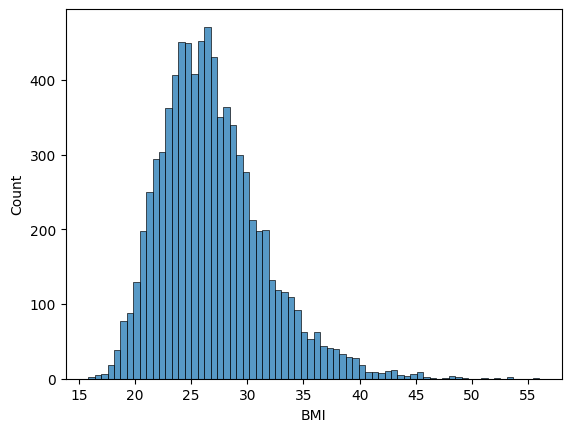

In [129]:
sns.histplot(df_clean_XY['BMI'])

In [131]:
df_clean_XY.BMI.mean()

26.92608336712181